# **BERT model**

BERT (Bidirectional Encoder Representations from Transformers) is a powerful pre-trained language model developed by Google. This notebook aims to demonstrate how to fine-tune a BERT model for a fake news detection task.

We will cover the following steps:
1.  **Data Loading and Preprocessing**: Load a dataset containing true and fake news, then preprocess it for BERT.
2.  **Model Configuration**: Set up the BERT model for sequence classification.
3.  **Training**: Fine-tune the BERT model using the prepared dataset.
4.  **Evaluation**: Assess the model's performance on a test set.
5.  **Prediction**: Use the fine-tuned model to predict the veracity of new texts.

In [ ]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset
from transformers import AutoModelForSequenceClassification
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from trl import SFTTrainer
from sklearn.metrics import classification_report, confusion_matrix
import os
import shutil
from google.colab import files
import matplotlib.pyplot as plt
from transformers import pipeline


In [ ]:
def check_gpu():
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU: {name}  |  VRAM: {mem:.1f} GB")
    else:
        print("No se ha detectado GPU")

check_gpu()

GPU: Tesla T4  |  VRAM: 15.6 GB


### **Defining Model Configuration Parameters**

This cell defines various hyperparameters and configuration settings for our BERT model and training process. These include the `MODEL_NAME` (which BERT variant to use), `MAX_LEN` for tokenization, `BATCH_SIZE` for training and evaluation, `EPOCHS`, `LEARNING_RATE`, `WEIGHT_DECAY`, `WARMUP_RATIO` for the optimizer, and `OUTPUT_DIR` for saving results. These parameters are crucial for controlling the training behavior and performance.

In [ ]:
# Parameters optimized for a T4 GPU avaiable in a Google Colab notebook
MODEL_NAME  = "bert-base-uncased"

MAX_LEN     = 256
BATCH_TRAIN = 32
BATCH_EVAL  = 64
EPOCHS      = 4
LR          = 2e-5
WEIGHT_DECAY= 0.01
WARMUP_RATIO= 0.1
OUTPUT_DIR  = "./bert_fakenews_trainer"
SEED        = 42

### **Loading and Preprocessing Data**

Here, we load the `True.csv` and `Fake.csv` datasets, assign labels (1 for true, 0 for fake), concatenate them, and perform basic text cleaning such as trimming and shortening the text. The data is then shuffled and split into training, validation, and test sets using `train_test_split` with stratification to maintain label distribution.

In [ ]:
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

df_true["label"] = 1
df_fake["label"] = 0

df = pd.concat([df_true, df_fake], ignore_index=True)
df["text"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()

# Recortar a 1500 caracteres (~250 tokens); el resto suele ser ruido
df["text"] = df["text"].str[:1500]

df = df[["text", "label"]].sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total: {len(df):,}  |  Verdaderas: {df.label.sum():,}  |  Falsas: {(df.label==0).sum():,}")

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

# Separar validación del train
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels,
    test_size=0.1,
    stratify=train_labels,
    random_state=SEED
)

print(f"Train: {len(train_texts):,}  |  Val: {len(val_texts):,}  |  Test: {len(test_texts):,}")

Total: 44,898  |  Verdaderas: 21,417  |  Falsas: 23,481
Train: 34,346  |  Val: 3,817  |  Test: 6,735


### **Tokenization and Dataset Preparation**

This section initializes the `AutoTokenizer` for our BERT model. The `tokenize` function prepares the text by converting it into numerical input IDs, attention masks, and token type IDs, also truncating and padding to `MAX_LEN`. The preprocessed data is then converted into `datasets.Dataset` objects and set to PyTorch format, making it ready for the `Trainer`.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts, labels):
    enc = tokenizer(
        texts,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
    )
    enc["labels"] = labels
    return enc

train_enc = Dataset.from_dict(tokenize(train_texts, train_labels))
val_enc   = Dataset.from_dict(tokenize(val_texts,   val_labels))
test_enc  = Dataset.from_dict(tokenize(test_texts,  test_labels))

train_enc.set_format("torch")
val_enc.set_format("torch")
test_enc.set_format("torch")

print(f"Columnas del dataset: {train_enc.column_names}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Columnas del dataset: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


### **Loading the BERT Model for Sequence Classification**

We load a pre-trained `AutoModelForSequenceClassification` from the Hugging Face Transformers library. This model is configured for a 2-class classification task (fake or true news) and includes mappings from label IDs to human-readable labels. The total and trainable parameters of the model are printed to provide an overview of its size.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "FALSA", 1: "VERDADERA"},
    label2id={"FALSA": 0, "VERDADERA": 1},
)

# Parámetros entrenables
total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {train_:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales:      109,483,778
Parámetros entrenables:  109,483,778


### **Defining Evaluation Metrics**

The `compute_metrics` function is essential for evaluating the model's performance during training and after. It calculates accuracy, F1-score (weighted), and AUC-ROC score based on the model's logits and the true labels. These metrics provide a comprehensive understanding of how well the model is performing.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds  = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted"),
        "auc":      roc_auc_score(labels, probs[:, 1]),
    }

### **Configuring Training Arguments and Trainer**

This cell sets up the `TrainingArguments` for the fine-tuning process, defining parameters such as the output directory, number of epochs, batch sizes, learning rate schedule, evaluation strategy, and logging preferences. It also initializes the `Trainer` object, which orchestrates the entire training and evaluation loop, integrating our model, datasets, tokenizer, metrics function, and early stopping callback.

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,

    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,

    gradient_accumulation_steps=2,

    # Optimizador y lr
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="linear",

    # Evaluación y guardado
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    # Logs
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",   #tensorboard

    seed=SEED,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_enc,
    eval_dataset=val_enc,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### **Executing Model Training**

In [ ]:
print("Iniciando entrenamiento...\n")
train_result = trainer.train()

print(f"\nTiempo total:  {train_result.metrics['train_runtime']:.0f} s")
print(f"Muestras/seg:  {train_result.metrics['train_samples_per_second']:.1f}")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModelo guardado en: {OUTPUT_DIR}/")

Iniciando entrenamiento...



Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.007741,0.009197,0.998690,0.998690,0.999992
2,0.004706,0.005004,0.998952,0.998952,1.000000
3,0.000075,0.001127,0.999738,0.999738,0.999999
4,0.000110,0.002156,0.999214,0.999214,0.999999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Tiempo total:  2018 s
Muestras/seg:  68.1


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo guardado en: ./bert_fakenews_trainer/


### **Evaluating Model on Test Set**

After training, the model's performance is rigorously evaluated on the unseen `test_enc` dataset. This block generates a classification report, which includes precision, recall, and F1-score for each class, as well as the confusion matrix and AUC-ROC score, providing a detailed assessment of the model's generalization capabilities.

In [ ]:
print("\n=== Evaluación en conjunto de TEST ===\n")
test_output = trainer.predict(test_enc)

logits      = test_output.predictions
y_pred      = np.argmax(logits, axis=-1)
y_true      = test_output.label_ids
probs       = torch.softmax(torch.tensor(logits), dim=-1).numpy()

print(classification_report(y_true, y_pred, target_names=["Falsa", "Verdadera"]))
print("Matriz de confusión:")
print(confusion_matrix(y_true, y_pred))
print(f"\nAUC-ROC: {roc_auc_score(y_true, probs[:,1]):.4f}")

In [ ]:
trainer.save_model("./bert_fakenews")
tokenizer.save_pretrained("./bert_fakenews")

print("Archivos guardados:")
for f in os.listdir("./bert_fakenews"):
    print(f"  {f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Archivos guardados:
  tokenizer_config.json
  model.safetensors
  config.json
  training_args.bin
  tokenizer.json


In [ ]:
# Comprimir la carpeta en un zip
shutil.make_archive("bert_fakenews", "zip", "./bert_fakenews")

# Descargar a tu máquina local
files.download("bert_fakenews.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.push_to_hub("MrFat/bert_fakenews_v1")
tokenizer.push_to_hub("MrFat/bert_fakenews_v1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...yhts92q/model.safetensors:  37%|###6      |  160MB /  438MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/MrFat/bert_fakenews_v1/commit/dcf1c8fd96adbcf6b487bf8aeb7b08e870bce0eb', commit_message='Upload tokenizer', commit_description='', oid='dcf1c8fd96adbcf6b487bf8aeb7b08e870bce0eb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/MrFat/bert_fakenews_v1', endpoint='https://huggingface.co', repo_type='model', repo_id='MrFat/bert_fakenews_v1'), pr_revision=None, pr_num=None)

### **Visualizing Training Curves**

This cell plots the training loss, validation F1-score, and validation accuracy over time. These plots are crucial for monitoring the training progress, identifying overfitting or underfitting, and understanding how well the model is learning and generalizing.

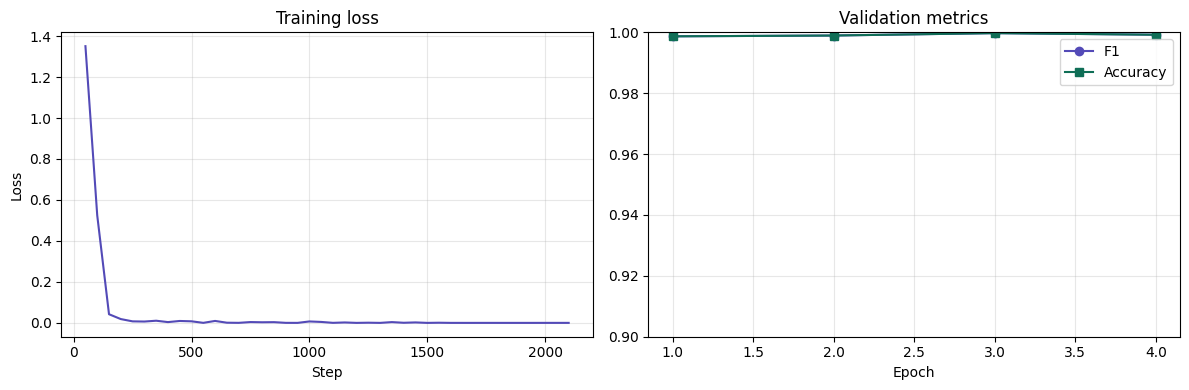

Curvas guardadas en training_curves.png


In [ ]:
log_history = trainer.state.log_history

train_loss = [(e["step"], e["loss"])       for e in log_history if "loss"     in e and "eval_loss" not in e]
eval_f1    = [(e["epoch"], e["eval_f1"])   for e in log_history if "eval_f1"  in e]
eval_acc   = [(e["epoch"], e["eval_accuracy"]) for e in log_history if "eval_accuracy" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, color="#534AB7", linewidth=1.5)
    axes[0].set_title("Training loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

if eval_f1 and eval_acc:
    epochs_f1,  f1s  = zip(*eval_f1)
    epochs_acc, accs = zip(*eval_acc)
    axes[1].plot(epochs_f1,  f1s,  marker="o", label="F1",       color="#534AB7")
    axes[1].plot(epochs_acc, accs, marker="s", label="Accuracy", color="#0F6E56")
    axes[1].set_title("Validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0.9, 1.0)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Curvas guardadas en training_curves.png")

### **Making Predictions on New Text**

This section demonstrates how to use the fine-tuned BERT model for inference on new, unseen text examples. It creates a `text-classification` pipeline and then applies it to a list of sample news headlines, showing the predicted label (FALSA/VERDADERA) and the confidence score for each prediction.

In [ ]:
classifier = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LEN,
)

noticias = [
    "NASA confirms water ice discovered on the Moon's south pole",
    "Government secretly adding mind-control chemicals to tap water since 1987",
    "Federal Reserve raises interest rates by 25 basis points amid inflation concerns",
    "Scientists discover eating chocolate daily adds 10 years to your life",
    "The Federal Reserve left interest rates unchanged on Wednesday, \
citing concerns about slowing economic growth and uncertainty in global markets. \
Fed Chair Janet Yellen said policymakers would continue to monitor inflation data \
before making any future adjustments to monetary policy.",
    "SHOCKING: Janet Yellen secretly admits the entire US economy is a \
massive fraud controlled by globalist elites. The truth they don't want you to know!"
]

print(f"\n{'Noticia':<65} {'Etiqueta':<12} {'Confianza'}")
print("-" * 90)
for noticia in noticias:
    result = classifier(noticia)[0]
    conf   = f"{result['score']:.2%}"
    print(f"{noticia[:65]:<65} {result['label']:<12} {conf}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Noticia                                                           Etiqueta     Confianza
------------------------------------------------------------------------------------------
NASA confirms water ice discovered on the Moon's south pole       FALSA        99.93%
Government secretly adding mind-control chemicals to tap water si FALSA        99.99%
Federal Reserve raises interest rates by 25 basis points amid inf FALSA        99.70%
Scientists discover eating chocolate daily adds 10 years to your  FALSA        100.00%
The Federal Reserve left interest rates unchanged on Wednesday, c VERDADERA    99.58%
SHOCKING: Janet Yellen secretly admits the entire US economy is a FALSA        100.00%
